In [1]:
import os, glob, random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

from datasets import VOCDataset, COCODataset, make_loaders


In [2]:
IMG_SIZE    = 416
BATCH_SIZE  = 32
LR          = 1e-4
EPOCHS_VOC  = 30
EPOCHS_COCO = 30

NUM_WORKERS = 4
torch.set_num_threads(NUM_WORKERS)
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

ANCHORS = [
    [(116, 90), (156, 198), (373, 326)],
    [(30,  61), (62,  45),  (59,  119)],
    [(10,  13), (16,  30),  (33,   23)],
]

VOC_TRAIN = [('data/VOC/VOC2007', 'train'), ('data/VOC/VOC2012', 'trainval')]
VOC_VAL   = [('data/VOC/VOC2007', 'test')]
VOC_CLASS_NAMES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor',
]
VOC_CLS2IDX = {n: i for i, n in enumerate(VOC_CLASS_NAMES)}

COCO_TRAIN_IMGS = 'data/COCO2017/train2017'
COCO_TRAIN_LBLS = 'data/COCO2017/labels/train2017'
COCO_VAL_IMGS   = 'data/COCO2017/val2017'
COCO_VAL_LBLS   = 'data/COCO2017/labels/val2017'
COCO_CLASS_NAMES = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
    'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack',
    'umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
    'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
    'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
    'couch','potted plant','bed','dining table','toilet','tv','laptop','mouse',
    'remote','keyboard','cell phone','microwave','oven','toaster','sink',
    'refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush',
]

print(f'device={DEVICE}  workers={NUM_WORKERS}')


device=mps  workers=4


In [3]:
voc_train_ds = VOCDataset(VOC_TRAIN, VOC_CLS2IDX, IMG_SIZE, augment_data=True,  cache=False)
voc_val_ds   = VOCDataset(VOC_VAL,   VOC_CLS2IDX, IMG_SIZE, augment_data=False, cache=False)
train_dl_voc, val_dl_voc = make_loaders(voc_train_ds, voc_val_ds, BATCH_SIZE, NUM_WORKERS)

coco_train_ds = COCODataset(COCO_TRAIN_IMGS, COCO_TRAIN_LBLS, IMG_SIZE, augment_data=True)
coco_val_ds   = COCODataset(COCO_VAL_IMGS,   COCO_VAL_LBLS,   IMG_SIZE, augment_data=False)
train_dl_coco, val_dl_coco = make_loaders(coco_train_ds, coco_val_ds, BATCH_SIZE, NUM_WORKERS)

print(f'VOC  train={len(voc_train_ds)}  val={len(voc_val_ds)}')
print(f'COCO train={len(coco_train_ds)}  val={len(coco_val_ds)}')


VOC  train=14041  val=4952
COCO train=118287  val=5000


In [4]:
def cbl(ic, oc, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv2d(ic, oc, k, s, p, bias=False),
        nn.BatchNorm2d(oc),
        nn.LeakyReLU(0.01, inplace=True),
    )


class Res(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.b = nn.Sequential(cbl(c, c // 2, 1, 1, 0), cbl(c // 2, c))

    def forward(self, x):
        return x + self.b(x)


def make5(ic, oc):
    return nn.Sequential(
        cbl(ic,     oc,     1, 1, 0),
        cbl(oc,     oc * 2         ),
        cbl(oc * 2, oc,     1, 1, 0),
        cbl(oc,     oc * 2         ),
        cbl(oc * 2, oc,     1, 1, 0),
    )


class YOLOv3(nn.Module):
    def __init__(self, nc=80):
        super().__init__()
        out = 3 * (5 + nc)

        self.d1 = nn.Sequential(
            cbl(3, 32), cbl(32, 64, s=2), Res(64),
            cbl(64, 128, s=2), Res(128), Res(128),
            cbl(128, 256, s=2), *[Res(256) for _ in range(8)],
        )
        self.d2 = nn.Sequential(
            cbl(256, 512, s=2), *[Res(512) for _ in range(8)],
        )
        self.d3 = nn.Sequential(
            cbl(512, 1024, s=2), *[Res(1024) for _ in range(4)],
        )

        self.c5_1 = make5(1024, 512)
        self.det1 = nn.Sequential(cbl(512, 1024), nn.Conv2d(1024, out, 1))

        self.up2  = nn.Sequential(cbl(512, 256, 1, 1, 0), nn.Upsample(scale_factor=2))
        self.c5_2 = make5(768, 256)
        self.det2 = nn.Sequential(cbl(256, 512), nn.Conv2d(512, out, 1))

        self.up3  = nn.Sequential(cbl(256, 128, 1, 1, 0), nn.Upsample(scale_factor=2))
        self.c5_3 = make5(384, 128)
        self.det3 = nn.Sequential(cbl(128, 256), nn.Conv2d(256, out, 1))

    def forward(self, x):
        c3 = self.d1(x)
        c4 = self.d2(c3)
        c5 = self.d3(c4)

        x1 = self.c5_1(c5);          o1 = self.det1(x1)
        x2 = self.c5_2(torch.cat([self.up2(x1), c4], 1)); o2 = self.det2(x2)
        x3 = self.c5_3(torch.cat([self.up3(x2), c3], 1)); o3 = self.det3(x3)
        return o1, o2, o3


# quick shape check
_m = YOLOv3(20)
_o = _m(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))
print(f'output shapes: {[tuple(x.shape) for x in _o]}')
print(f'{sum(p.numel() for p in _m.parameters()) / 1e6:.1f}M params')
del _m, _o


output shapes: [(1, 75, 13, 13), (1, 75, 26, 26), (1, 75, 52, 52)]
61.6M params


In [5]:
def load_pretrained_backbone(model):
    import timm
    src = timm.create_model('darknet53', pretrained=True)
    src.eval()

    def copy_cbl(s, d):
        # s = timm cbl (has .conv and .bn)
        # d = our cbl (nn.Sequential: [Conv2d, BatchNorm2d, LeakyReLU])
        d[0].weight.data.copy_(s.conv.weight.data)
        for attr in ('weight', 'bias', 'running_mean', 'running_var', 'num_batches_tracked'):
            getattr(d[1], attr).data.copy_(getattr(s.bn, attr).data)

    def copy_res(s_block, d_res):
        # s_block = timm ResBlock (has .conv1 and .conv2)
        # d_res   = our Res module (has .b which is Sequential of two cbls)
        copy_cbl(s_block.conv1, d_res.b[0])
        copy_cbl(s_block.conv2, d_res.b[1])

    s = src
    d = model

    # d1: cbl + cbl + Res(1) + cbl + Res(2) + cbl + Res(8)
    copy_cbl(s.stem.conv1,          d.d1[0])
    copy_cbl(s.stages[0].conv_down, d.d1[1])
    copy_res(s.stages[0].blocks[0], d.d1[2])
    copy_cbl(s.stages[1].conv_down, d.d1[3])
    copy_res(s.stages[1].blocks[0], d.d1[4])
    copy_res(s.stages[1].blocks[1], d.d1[5])
    copy_cbl(s.stages[2].conv_down, d.d1[6])
    for i in range(8):
        copy_res(s.stages[2].blocks[i], d.d1[7 + i])

    # d2: cbl + Res(8)
    copy_cbl(s.stages[3].conv_down, d.d2[0])
    for i in range(8):
        copy_res(s.stages[3].blocks[i], d.d2[1 + i])

    # d3: cbl + Res(4)
    copy_cbl(s.stages[4].conv_down, d.d3[0])
    for i in range(4):
        copy_res(s.stages[4].blocks[i], d.d3[1 + i])

    del src
    print('pretrained Darknet-53 backbone loaded')


def freeze_backbone(model, freeze=True):
    for m in (model.d1, model.d2, model.d3):
        for p in m.parameters():
            p.requires_grad_(not freeze)
    state = 'frozen' if freeze else 'unfrozen'
    print(f'backbone {state}')


In [6]:
class YOLOLoss(nn.Module):
    def __init__(self, anchors, nc, img_size):
        super().__init__()
        self.register_buffer('anc', torch.tensor(anchors, dtype=torch.float32) / img_size)
        self.na  = len(anchors)
        self.nc  = nc
        self.bce = nn.BCEWithLogitsLoss()
        self.mse = nn.MSELoss()

    def forward(self, pred, targets):
        B, _, G, _ = pred.shape
        pred = pred.view(B, self.na, 5 + self.nc, G, G).permute(0, 1, 3, 4, 2).contiguous()

        obj   = torch.zeros(B, self.na, G, G,           dtype=torch.bool,  device=pred.device)
        noobj = torch.ones (B, self.na, G, G,           dtype=torch.bool,  device=pred.device)
        txy   = torch.zeros(B, self.na, G, G, 2,        device=pred.device)
        twh   = torch.zeros(B, self.na, G, G, 2,        device=pred.device)
        tcls  = torch.zeros(B, self.na, G, G, self.nc,  device=pred.device)

        for b in range(B):
            for box in targets[b]:
                c, cx, cy, bw, bh = box.tolist()
                gx, gy = cx * G, cy * G
                gi = min(int(gx), G - 1)
                gj = min(int(gy), G - 1)
                wh  = torch.tensor([bw, bh], device=pred.device)
                iou = (torch.min(wh, self.anc).prod(1) /
                       (wh.prod() + self.anc.prod(1) - torch.min(wh, self.anc).prod(1) + 1e-8))
                a   = iou.argmax().item()
                obj  [b, a, gj, gi]         = True
                noobj[b, a, gj, gi]         = False
                txy  [b, a, gj, gi]         = torch.tensor([gx - gi, gy - gj], device=pred.device)
                twh  [b, a, gj, gi]         = torch.log(wh / self.anc[a] + 1e-8)
                tcls [b, a, gj, gi, int(c)] = 1.0

        has = obj.any()
        z   = pred.sum() * 0

        with torch.no_grad():
            anc     = self.anc.view(1, self.na, 1, 1, 2)
            pred_wh = torch.exp(pred[..., 2:4].clamp(-4, 4)) * anc
            tgt_wh  = torch.exp(twh) * anc
            inter   = torch.min(pred_wh, tgt_wh).prod(-1)
            iou_tgt = (inter / (pred_wh.prod(-1) + tgt_wh.prod(-1) - inter + 1e-8)).clamp(0, 1)

        lxy    = self.bce(pred[..., :2][obj],  txy[obj])                           if has else z
        lwh    = self.mse(pred[..., 2:4][obj], twh[obj])                           if has else z
        lcls   = self.bce(pred[..., 5:][obj],  tcls[obj])                          if has else z
        lobj   = self.mse(torch.sigmoid(pred[..., 4][obj]),   iou_tgt[obj])        if has else z
        lnoobj = self.bce(pred[..., 4][noobj], torch.zeros_like(pred[..., 4][noobj]))

        return lxy + lwh + lobj + 0.5 * lnoobj + lcls


In [7]:
def decode(pred, anchors, img_size):
    B, na, G, _, _ = pred.shape
    anc  = torch.tensor(anchors, dtype=torch.float32, device=pred.device) / img_size
    gy, gx = torch.meshgrid(
        torch.arange(G, device=pred.device),
        torch.arange(G, device=pred.device),
        indexing='ij',
    )
    grid  = torch.stack([gx, gy], -1).float().view(1, 1, G, G, 2)
    xy    = (pred[..., :2].sigmoid() + grid) / G
    wh    = pred[..., 2:4].exp() * anc.view(1, na, 1, 1, 2)
    obj   = pred[..., 4:5].sigmoid()
    cls   = pred[..., 5:].sigmoid()
    boxes = torch.cat([xy - wh / 2, xy + wh / 2], -1)
    return boxes, obj, cls


def nms(boxes, scores, thr=0.45):
    order = scores.argsort(descending=True)
    keep  = []
    while order.numel():
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        x1 = boxes[rest, 0].clamp(min=boxes[i, 0].item())
        y1 = boxes[rest, 1].clamp(min=boxes[i, 1].item())
        x2 = boxes[rest, 2].clamp(max=boxes[i, 2].item())
        y2 = boxes[rest, 3].clamp(max=boxes[i, 3].item())
        inter = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
        a1    = (boxes[i, 2] - boxes[i, 0]) * (boxes[i, 3] - boxes[i, 1])
        a2    = (boxes[rest, 2] - boxes[rest, 0]) * (boxes[rest, 3] - boxes[rest, 1])
        order = rest[inter / (a1 + a2 - inter + 1e-6) < thr]
    return keep


def box_iou_vec(box, boxes):
    x1 = boxes[:, 0].clamp(min=box[0].item())
    y1 = boxes[:, 1].clamp(min=box[1].item())
    x2 = boxes[:, 2].clamp(max=box[2].item())
    y2 = boxes[:, 3].clamp(max=box[3].item())
    inter = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    a1 = (box[2] - box[0]) * (box[3] - box[1])
    a2 = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return inter / (a1 + a2 - inter + 1e-6)


def compute_map(loader, nc, iou_thr=0.5, conf=0.25, nms_iou=0.45):
    model.eval()
    all_stats = []
    n_gt      = torch.zeros(nc, dtype=torch.long)

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc='  mAP@0.5', leave=False):
            B    = imgs.shape[0]
            imgs = imgs.to(DEVICE)
            outs = model(imgs)

            for b in range(B):
                pb, ps, pc = [], [], []
                for out, anc in zip(outs, ANCHORS):
                    _, _, G, _ = out.shape
                    p = (out[b:b+1]
                         .view(1, 3, 5 + nc, G, G)
                         .permute(0, 1, 3, 4, 2).contiguous())
                    bx, ob, cl = decode(p, anc, IMG_SIZE)
                    s, ci = (ob * cl).max(-1)
                    mask  = s.squeeze(0) > conf
                    pb.append(bx.squeeze(0)[mask])
                    ps.append(s.squeeze(0)[mask])
                    pc.append(ci.squeeze(0)[mask])

                pb = torch.cat(pb); ps = torch.cat(ps); pc = torch.cat(pc)
                if pb.shape[0] > 0:
                    keep = nms(pb, ps, nms_iou)
                    pb = pb[keep]; ps = ps[keep]; pc = pc[keep]

                pb = pb.cpu(); ps = ps.cpu(); pc = pc.cpu()

                gt = targets[b]
                for box in gt:
                    n_gt[int(box[0].item())] += 1

                if pb.shape[0] == 0 or gt.shape[0] == 0:
                    continue

                gt_xyxy  = torch.cat([gt[:, 1:3] - gt[:, 3:5] / 2,
                                      gt[:, 1:3] + gt[:, 3:5] / 2], -1)
                gt_cls   = gt[:, 0].long()
                detected = torch.zeros(gt.shape[0], dtype=torch.bool)

                for di in ps.argsort(descending=True):
                    pcls  = int(pc[di].item())
                    same  = (gt_cls == pcls) & ~detected
                    is_tp = 0
                    if same.any():
                        ious   = box_iou_vec(pb[di], gt_xyxy[same])
                        bv, bj = ious.max(0)
                        if bv.item() >= iou_thr:
                            detected[same.nonzero(as_tuple=True)[0][bj]] = True
                            is_tp = 1
                    all_stats.append((ps[di].item(), is_tp, pcls))

    aps = []
    for c in range(nc):
        if n_gt[c] == 0:
            continue
        dets = [(s, tp) for s, tp, cl in all_stats if cl == c]
        if not dets:
            aps.append(0.0)
            continue
        dets.sort(reverse=True)
        tp_arr = np.array([d[1] for d in dets], dtype=np.float32)
        tp_cum = np.cumsum(tp_arr)
        fp_cum = np.cumsum(1 - tp_arr)
        rec    = tp_cum / n_gt[c].item()
        prec   = tp_cum / (tp_cum + fp_cum)
        ap = sum(
            (prec[rec >= t].max() if (rec >= t).any() else 0.0)
            for t in np.linspace(0, 1, 11)
        ) / 11
        aps.append(float(ap))

    return float(np.mean(aps)) if aps else 0.0


In [10]:
def train_run(train_dl, val_dl, epochs, tag, nc, freeze_epochs=10):
    opt      = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=5e-4)
    sched    = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[int(epochs*0.6), int(epochs*0.8)], gamma=0.1)
    best_map = 0.0
    hist     = {'train': [], 'val': [], 'map': []}

    for epoch in range(1, epochs + 1):
        if freeze_epochs > 0 and epoch == freeze_epochs + 1:
            freeze_backbone(model, freeze=False)

        model.train()
        t_loss = 0.0
        bar = tqdm(train_dl, desc=f'  [{tag}] {epoch}/{epochs} train', leave=False)
        for imgs, targets in bar:
            imgs = imgs.to(DEVICE)
            loss = sum(c(p, targets) for c, p in zip(criteria, model(imgs)))
            opt.zero_grad(); loss.backward(); opt.step()
            t_loss += loss.item()
            bar.set_postfix(loss=f'{loss.item():.3f}')
        t_loss /= len(train_dl)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for imgs, targets in tqdm(val_dl, desc=f'  [{tag}] {epoch}/{epochs} val', leave=False):
                v_loss += sum(c(p, targets) for c, p in zip(criteria, model(imgs.to(DEVICE)))).item()
        v_loss /= len(val_dl)

        curr_map = compute_map(val_dl, nc=nc)
        saved = curr_map > best_map
        if saved:
            best_map = curr_map
            torch.save(model.state_dict(), f'yolov3_{tag}_best.pt')

        hist['train'].append(t_loss)
        hist['val'].append(v_loss)
        hist['map'].append(curr_map)

        sched.step()
        print(f'[{tag}] epoch {epoch:>3}/{epochs}  train={t_loss:.3f}  val={v_loss:.3f}  mAP50={curr_map:.4f}  best={best_map:.4f}{"  *" if saved else ""}', flush=True)

    return hist


In [9]:
NC_VOC   = len(VOC_CLASS_NAMES)
model    = YOLOv3(NC_VOC).to(DEVICE)
criteria = [YOLOLoss(anc, NC_VOC, IMG_SIZE).to(DEVICE) for anc in ANCHORS]
load_pretrained_backbone(model)
freeze_backbone(model, freeze=True)
hist_voc = train_run(train_dl_voc, val_dl_voc, EPOCHS_VOC, tag='voc', nc=NC_VOC, freeze_epochs=5)


pretrained Darknet-53 backbone loaded
backbone frozen


  [voc] 1/30 train:   0%|          | 0/439 [00:00<?, ?it/s]

  [voc] 1/30 val:   0%|          | 0/155 [00:00<?, ?it/s]

  mAP@0.5:   0%|          | 0/155 [00:00<?, ?it/s]

[voc] epoch   1/30  train=3.974  val=3.256  mAP50=0.0490  best=0.0490  *


...

[voc] epoch  29/30  train=1.661  val=2.613  mAP50=0.6463  best=0.6536


  [voc] 30/30 train:   0%|          | 0/439 [00:00<?, ?it/s]

  [voc] 30/30 val:   0%|          | 0/155 [00:00<?, ?it/s]

  mAP@0.5:   0%|          | 0/155 [00:00<?, ?it/s]

[voc] epoch  30/30  train=1.657  val=2.619  mAP50=0.6471  best=0.6536


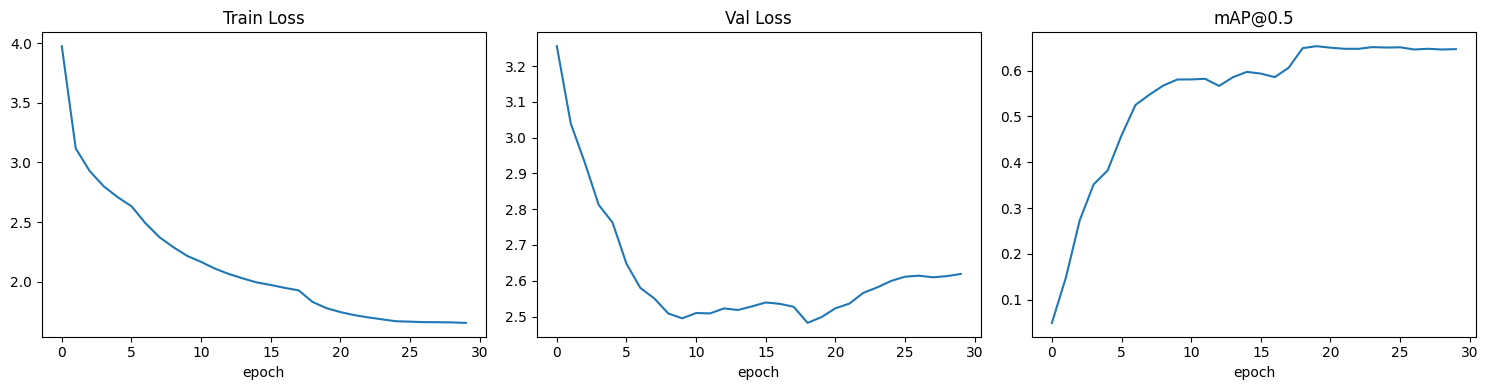

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ('train', 'val', 'map'), ('Train Loss', 'Val Loss', 'mAP@0.5')):
    ax.plot(hist_voc[key])
    ax.set_title(title); ax.set_xlabel('epoch')
plt.tight_layout(); plt.show()


In [ ]:
NC_COCO  = len(COCO_CLASS_NAMES)        
model    = YOLOv3(NC_COCO).to(DEVICE)       
criteria = [YOLOLoss(anc, NC_COCO,                
IMG_SIZE).to(DEVICE) for anc in ANCHORS]    
load_pretrained_backbone(model)                   
freeze_backbone(model, freeze=True)             
hist_coco = train_run(train_dl_coco, val_dl_coco, EPOCHS_COCO, tag='coco', nc=NC_COCO,freeze_epochs=5)
